# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('air_fryers_clean_brand_year.csv')

In [ ]:
# Q-1-1

# Task 1: Verify 10 brands and years 2019-2023
num_brands = df['brand'].nunique()
years_covered = sorted(df['year'].unique())

print(f"Number of unique brands: {num_brands}")
print(f"Years in dataset: {years_covered}")

Number of unique brands: 10
Years in dataset: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


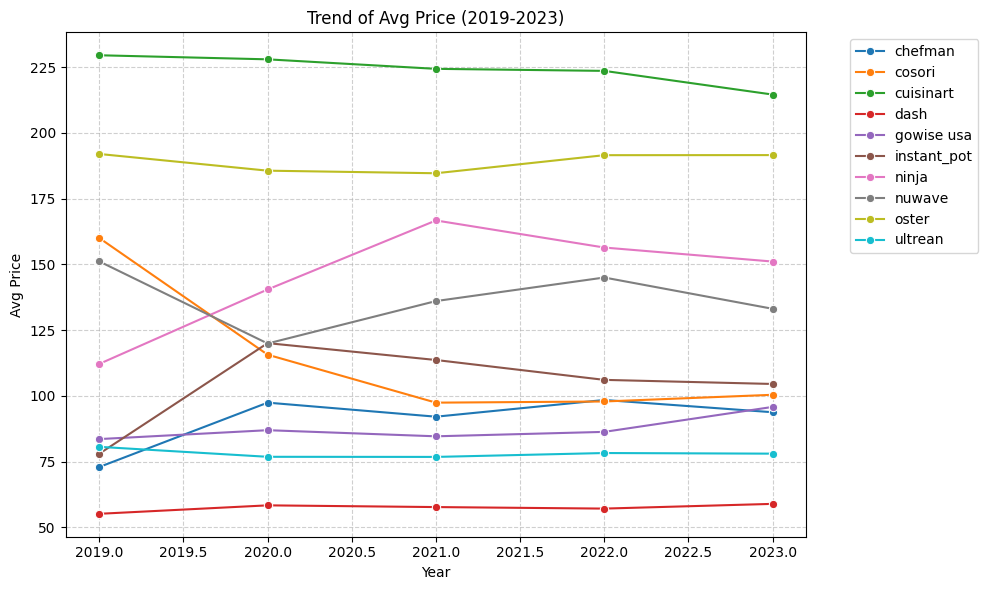

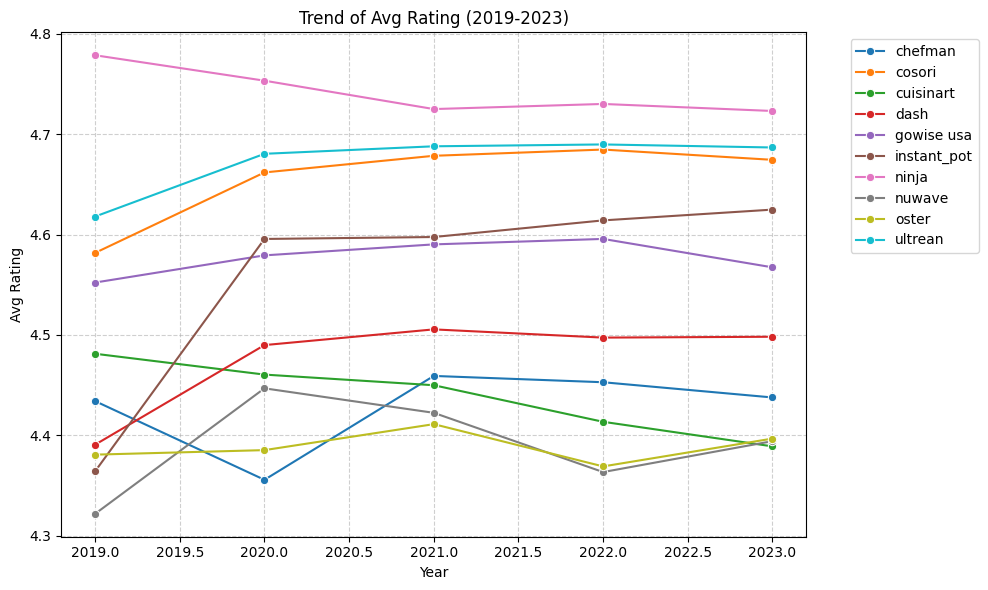

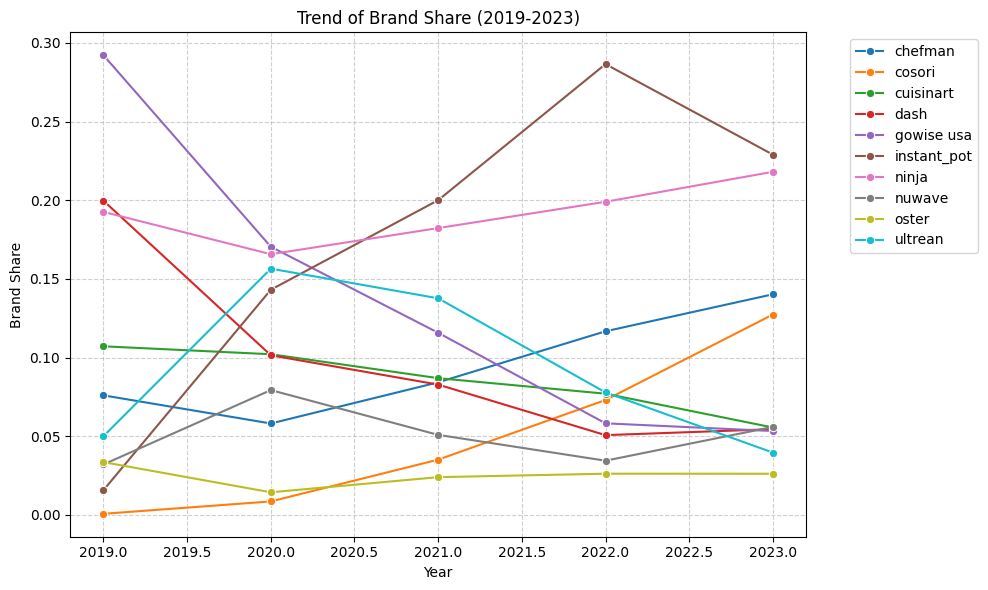

In [ ]:
# Q-1-2

# --- Task 2: Plot trends over time by brand ---
metrics = ['avg_price', 'avg_rating', 'brand_share']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x='year', y=metric, hue='brand', marker='o')
    plt.title(f'Trend of {metric.replace("_", " ").title()} (2019-2023)')
    plt.ylabel(metric.replace("_", " ").title())
    plt.xlabel('Year')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
#Q-1-3

# --- Task 3: Summarize Product Characteristics ---
# List of characteristic share columns
char_cols = ['compact_share', 'dual_basket_share', 'oven_style_share',
             'rotisserie_share', 'window_share']

# Calculate mean share across all observations
avg_characteristics = df[char_cols].mean().sort_values(ascending=False)
print("\nAverage Product Characteristic Shares across the market:")
print(avg_characteristics)

# Pivot to see which brands specialize in which features
brand_specialization = df.groupby('brand')[char_cols].mean()
print("\nCharacteristic specialization by Brand (Mean Share):")
print(brand_specialization)


Average Product Characteristic Shares across the market:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64

Characteristic specialization by Brand (Mean Share):
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000        

# Answer to Q-1-3

The most dominant feature is compact_share, with a market-wide average of approximately 98%. This suggests that nearly every product in this top-10 dataset is categorized as 'compact'. The second most common feature is oven_style_share at 56.3%. This indicates that more than half of the air fryers produced by these brands follow the oven-style design rather than the traditional basket-only design.


The most rare features are dual_basket_share (0.2%),
window_share (3.7%), and rotisserie_share (7.1%).


Several brands focus heavily on the oven-style form factor: Cuisinart (91.3%),Dash (89.0%), Oster (86.4%), Ultrean (83.0%). These brands have moved away from the "standard" basket design and focus on the countertop oven aesthetic.

Chefman stands out as the most diversified brand in terms of features. Chefman specializes in the rarer features: window_share (36.3%), suggesting it is the go-to brand for users who want to see their food cooking. It also is the highest rotisserie_share (37.0%), nearly double its closest competitor.

Cosori and Ninja appear to be in the "Standard Basket". Cosori has a very low oven_style_share (3.0%), meaning 97% of its products are likely traditional basket fryers. Ninja similarly keeps a low oven_style_share (10.0%) and avoids the rotisserie and window features almost entirely.

# Answer to Q-1-4

The air fryer market from 2019–2023 appears to be characterized by high product differentiation and significant shifts in leadership, suggesting a dynamic and competitive landscape rather than a stable one. Cuisinart is consistently the most expensive brand, maintaining a price point above $200, followed by Oster and Ninja. Interestingly, these expensive brands tend to specialize in "Oven-Style" models. In terms of Lareg-Share-Brands, market leadership has shifted dramatically. While GoWise USA started with the largest share in 2019, it has since declined. As of 2023, Instant Pot and Ninja have emerged as the dominant players, each holding roughly 20–25% of the market share. Cosori has also shown aggressive growth, moving from nearly 0% to a top-tier position. The market does not look stable over time. We see "churn" in brand dominance, with early leaders losing ground to newer entrants like Instant Pot and Cosori. Pricing is also volatile; for instance, Ninja’s average price saw a significant spike in 2021 before tapering off, and NuWave experienced a sharp price drop followed by a recovery. These fluctuations in both price and share indicate a market still searching for equilibrium as brands experiment with different feature sets—like Chefman’s focus on windows and rotisseries—to capture consumer interest.
